In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Cleaned_dataset_shuffled.csv")


In [3]:
df['decisions'].head(10)

0    Feedback mechanism included | No quality stand...
1    Role establishes authority | Task is specific ...
2    Functional but not optimized | Missing output ...
3    Fragmented input | Missing role/task/output el...
4    Scope clearly defined | Clear role definition ...
5    Actionable instructions | Lacks prioritization...
6    Ambiguous target audience | Technical requirem...
7    Partial structure present but incomplete | Som...
8    Missing data source | Detailed methodology inc...
9    Basic structure exists | Key information parti...
Name: decisions, dtype: str

In [4]:
## Quick check to see all unique decision tags
all_decisions = df['decisions'].str.split('|').explode().str.strip()
print(all_decisions.value_counts())
print(f"\nTotal unique tags: {all_decisions.nunique()}")

decisions
Professional tone maintained         1560
Feedback mechanism included           920
Technical requirements clear          918
Unclear ownership                     909
Ambiguous target audience             908
                                     ... 
High risk of misunderstanding         491
Fragmented input                      483
Missing role/task/output elements     483
Ambiguous scope                       483
Likely to produce poor results        483
Name: count, Length: 99, dtype: int64

Total unique tags: 99


In [5]:
# Check average number of tags per prompt
df['tag_count'] = df['decisions'].str.split('|').apply(len)
print(f"Avg tags per prompt: {df['tag_count'].mean():.2f}")
print(f"Min tags: {df['tag_count'].min()}")
print(f"Max tags: {df['tag_count'].max()}")

## Check tag distribution
print(f"\nMost common tags:\n{all_decisions.value_counts().head(15)}")
print(f"\nRarest tags:\n{all_decisions.value_counts().tail(10)}")


Avg tags per prompt: 3.75
Min tags: 2
Max tags: 5

Most common tags:
decisions
Professional tone maintained    1560
Feedback mechanism included      920
Technical requirements clear     918
Unclear ownership                909
Ambiguous target audience        908
Assumptions documented           901
Missing examples                 901
Measurable outcomes stated       898
No quality standards             897
Clear role definition            894
Actionable instructions          890
Missing data source              890
Dependencies outlined            888
Incomplete background info       887
Reference materials cited        884
Name: count, dtype: int64

Rarest tags:
decisions
Task unclear                          496
Cannot determine success criteria     496
Casual tone inappropriate for task    491
Key parameters missing                491
Unclear objectives                    491
High risk of misunderstanding         491
Fragmented input                      483
Missing role/task/outp

In [6]:
# !pip install xgboost

In [7]:
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
from xgboost import XGBClassifier

In [8]:
le = LabelEncoder()
df['task_type_encoded'] = le.fit_transform(df['task_type'])

In [9]:
features = ['clarity', 'specificity', 'structure', 'constraints',
            'prompt_length', 'prompt_word_count',
            'task_type_encoded', 'keyword_density']

X = df[features]

In [10]:
mlb = MultiLabelBinarizer()
df['decisions_list'] = df['decisions'].str.split('|').apply(
    lambda x: [i.strip() for i in x]
)
y = mlb.fit_transform(df['decisions_list'])
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")  # expect (20000, 99)

X shape: (20000, 8)
y shape: (20000, 99)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [13]:
base_clf = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
model = MultiOutputClassifier(base_clf, n_jobs=-1)
model.fit(X_train, y_train)
print("Training done")

Training done


In [14]:
# Get probabilities instead of hard predictions
y_pred_proba = np.array([clf.predict_proba(X_test)[:, 1]
                          for clf in model.estimators_]).T

threshold = 0.14
y_pred_thresh = (y_pred_proba >= threshold).astype(int)

print(f"Initial threshold: {threshold}")

Initial threshold: 0.14


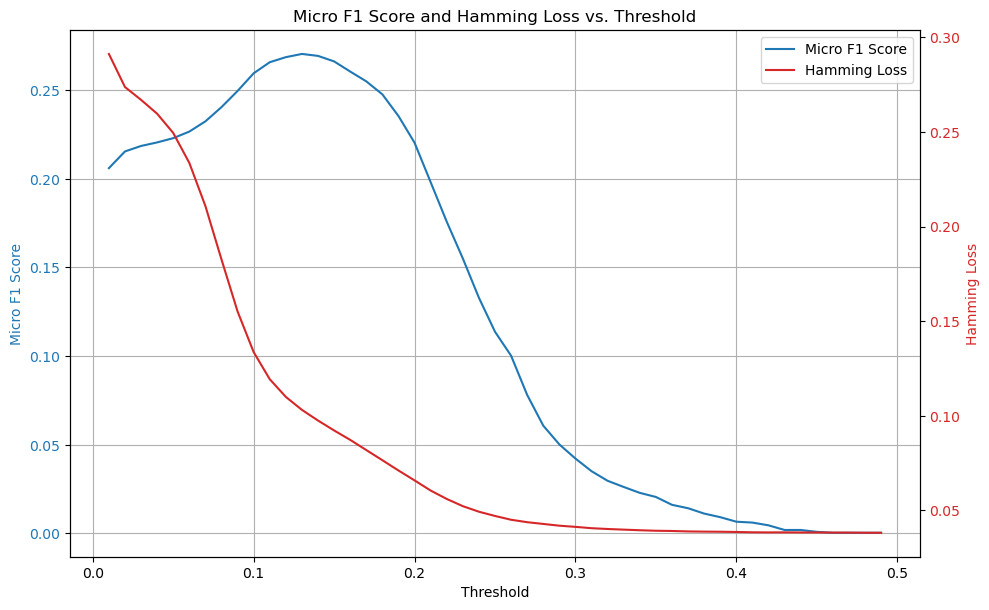

In [15]:
import matplotlib.pyplot as plt

# Calculate F1 and Hamming Loss for a range of thresholds
thresholds = np.arange(0.01, 0.5, 0.01)  # Using a finer range of thresholds
f1_scores = []
hamming_losses = []

for thresh in thresholds:
    y_pred_t = (y_pred_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, average='micro'))
    hamming_losses.append(hamming_loss(y_test, y_pred_t))

# Plotting the results
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Micro F1 Score', color=color)
ax1.plot(thresholds, f1_scores, color=color, label='Micro F1 Score')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Hamming Loss', color=color)  # we already handled the x-label with ax1
ax2.plot(thresholds, hamming_losses, color=color, label='Hamming Loss')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Micro F1 Score and Hamming Loss vs. Threshold')
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

In [16]:
sample_idx = 0
predicted_tags = mlb.inverse_transform(y_pred_thresh[sample_idx:sample_idx+1])
actual_tags    = mlb.inverse_transform(y_test[sample_idx:sample_idx+1])
print(f"\nActual tags   : {actual_tags}")
print(f"Predicted tags: {predicted_tags}")


Actual tags   : [('Ambiguous scope', 'Fragmented input', 'Likely to produce poor results', 'Missing role/task/output elements')]
Predicted tags: [('Ambiguous scope', 'Cannot determine success criteria', 'Casual tone inappropriate for task', 'Extremely vague request', 'Fragmented input', 'High hallucination risk', 'High risk of misunderstanding', 'Key parameters missing', 'Likely to produce poor results', 'Missing critical information', 'Missing role/task/output elements', 'No context provided', 'No structure or organization', 'Task unclear', 'Unclear objectives', 'Unprofessional presentation')]


In [17]:
# Setting threshold of 0.14
threshold = 0.14
y_pred_thresh = (y_pred_proba >= threshold).astype(int)

# Re-evaluate
print(f"Micro F1      : {f1_score(y_test, y_pred_thresh, average='micro'):.4f}")
print(f"Macro F1      : {f1_score(y_test, y_pred_thresh, average='macro'):.4f}")
print(f"Hamming Loss  : {hamming_loss(y_test, y_pred_thresh):.4f}")
print(f"Subset Accuracy: {accuracy_score(y_test, y_pred_thresh):.4f}")

# Sanity check same sample
predicted_tags = mlb.inverse_transform(y_pred_thresh[sample_idx:sample_idx+1])
actual_tags    = mlb.inverse_transform(y_test[sample_idx:sample_idx+1])
print(f"\nActual tags   : {actual_tags}")
print(f"Predicted tags: {predicted_tags}")

Micro F1      : 0.2693
Macro F1      : 0.2083
Hamming Loss  : 0.0974
Subset Accuracy: 0.0008

Actual tags   : [('Ambiguous scope', 'Fragmented input', 'Likely to produce poor results', 'Missing role/task/output elements')]
Predicted tags: [('Ambiguous scope', 'Cannot determine success criteria', 'Casual tone inappropriate for task', 'Extremely vague request', 'Fragmented input', 'High hallucination risk', 'High risk of misunderstanding', 'Key parameters missing', 'Likely to produce poor results', 'Missing critical information', 'Missing role/task/output elements', 'No context provided', 'No structure or organization', 'Task unclear', 'Unclear objectives', 'Unprofessional presentation')]


In [18]:
for thresh in [0.1, 0.15, 0.2, 0.25, 0.3]:
    y_pred_t = (y_pred_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_t, average='micro')
    hl = hamming_loss(y_test, y_pred_t)
    print(f"Threshold {thresh} → Micro F1: {f1:.4f} | Hamming Loss: {hl:.4f}")

Threshold 0.1 → Micro F1: 0.2595 | Hamming Loss: 0.1336
Threshold 0.15 → Micro F1: 0.2662 | Hamming Loss: 0.0922
Threshold 0.2 → Micro F1: 0.2203 | Hamming Loss: 0.0658
Threshold 0.25 → Micro F1: 0.1138 | Hamming Loss: 0.0470
Threshold 0.3 → Micro F1: 0.0423 | Hamming Loss: 0.0412
